# EDA: Merged Dataset (Properly Preprocessed)

This notebook analyzes the properly preprocessed merged dataset and focuses on:

- Basic trust checks first (missing values, validity ranges, continuity).
- Core exploratory visuals (temporal, network, weather, price).
- A focused context section around the Russia-Ukraine conflict period.

The analysis is descriptive and observational, not causal.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual style: colorful but readable
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10

In [2]:
PALETTE = {
    "consumption": "#2a9d8f",
    "consumption_dark": "#1f6f78",
    "price": "#e76f51",
    "price_dark": "#b23a48",
    "temperature": "#457b9d",
    "holiday": "#f4a261",
    "non_holiday": "#264653",
    "event": "#d62828",
}

NETWORK_COLORS = {
    "consumption_gasnet": "#ff6b6b",
    "consumption_jmpnet": "#4dabf7",
    "consumption_smpnet": "#ffd166",
    "consumption_vcpnet": "#80ed99",
}

NETWORK_LABELS = {
    "consumption_gasnet": "GasNet",
    "consumption_jmpnet": "JMPNet",
    "consumption_smpnet": "SMPNet",
    "consumption_vcpnet": "VCPNet",
}

WEEKDAY_NAMES = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun",
}

In [3]:
def style_axis(ax, title: str, xlabel: str = "", ylabel: str = "") -> None:
    ax.set_title(title, pad=12, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)

In [4]:
csv_path = Path("../data/preprocessed/merged_all_years_preprocessed.csv")

df = pd.read_csv(csv_path)
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]], errors="coerce")
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Loaded: {csv_path}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print(f"Range: {df['datetime'].min()} -> {df['datetime'].max()}")

Loaded: ..\data\preprocessed\merged_all_years_preprocessed.csv
Rows: 113,952 | Columns: 30
Range: 2013-01-01 00:00:00 -> 2025-12-31 23:00:00


## 1 Basic Dataset Overview

In [5]:
display(df.head(3))

summary = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "date_min",
            "date_max",
            "unique_years",
            "memory_mb",
        ],
        "value": [
            len(df),
            df.shape[1],
            df["datetime"].min(),
            df["datetime"].max(),
            df["year"].nunique(),
            round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        ],
    }
)

,year,month,day,hour,day_of_week,holiday,before_holiday,consumption_gasnet,consumption_jmpnet,consumption_smpnet,...,apparent_temperature,wind_gusts_10m,precipitation,snowfall,snow_depth,traded_volume_mwh,weighted_avg_price_eur_mwh,min_price_eur_mwh,max_price_eur_mwh,datetime
0,2013,1,1,0,1,1,0,309647.0,266965.0,165229.0,...,-3.640714,17.64,0.0,0.0,0.0,4068.7875,22.812143,21.925667,23.7325,2013-01-01 00:00:00
1,2013,1,1,1,1,1,0,317580.0,268874.0,144587.0,...,-4.358559,14.40,0.0,0.0,0.0,4068.7875,22.812143,21.925667,23.7325,2013-01-01 01:00:00
2,2013,1,1,2,1,1,0,306847.0,264634.0,159128.0,...,-5.120251,13.32,0.0,0.0,0.0,4068.7875,22.812143,21.925667,23.7325,2013-01-01 02:00:00


In [6]:
display(summary)

,metric,value
0,rows,113952
1,columns,30
2,date_min,2013-01-01 00:00:00
3,date_max,2025-12-31 23:00:00
4,unique_years,13
5,memory_mb,26.08


In [7]:
display(df.dtypes.to_frame("dtype"))

,dtype
year,int64
month,int64
day,int64
hour,int64
day_of_week,int64
holiday,int64
before_holiday,int64
consumption_gasnet,float64
consumption_jmpnet,float64
consumption_smpnet,float64


In [8]:
year_counts = df.groupby("year").size().rename("rows").to_frame()
display(year_counts.T)

year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
rows,8760,8760,8760,8784,8760,8760,8760,8784,8760,8760,8760,8784,8760


## 2 Baseline Data Quality Checks

These checks are descriptive (no hard-fail assertions).

In [9]:
consumption_cols = [
    "consumption_gasnet",
    "consumption_jmpnet",
    "consumption_smpnet",
    "consumption_vcpnet",
    "consumption_total",
]

price_cols = [
    "traded_volume_mwh",
    "weighted_avg_price_eur_mwh",
    "min_price_eur_mwh",
    "max_price_eur_mwh",
]

weather_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "pressure_msl",
    "surface_pressure",
    "dew_point_2m",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "apparent_temperature",
    "wind_gusts_10m",
    "precipitation",
    "snowfall",
    "snow_depth",
]

nan_total = int(df.isna().sum().sum())
nan_by_col = df.isna().sum().sort_values(ascending=False)

duplicate_timestamps = int(df["datetime"].duplicated().sum())

time_delta_counts = df["datetime"].diff().value_counts(dropna=False)
non_hourly_gaps = int((df["datetime"].diff().dropna() != pd.Timedelta(hours=1)).sum())

invalid_counts = {
    "consumption_total_non_positive": int((df["consumption_total"] <= 0).sum()),
    "weighted_avg_price_non_positive": int(
        (df["weighted_avg_price_eur_mwh"] <= 0).sum()
    ),
    "weighted_avg_price_above_500": int((df["weighted_avg_price_eur_mwh"] > 500).sum()),
    "max_price_above_500": int((df["max_price_eur_mwh"] > 500).sum()),
}

component_sum = df[
    [
        "consumption_gasnet",
        "consumption_jmpnet",
        "consumption_smpnet",
        "consumption_vcpnet",
    ]
].sum(axis=1)
total_diff = (df["consumption_total"] - component_sum).abs()
component_mismatch_rows = int((total_diff > 1e-6).sum())

quality_overview = pd.DataFrame(
    {
        "check": [
            "total NaNs",
            "duplicate timestamps",
            "non-hourly timestamp gaps",
            "consumption_total <= 0",
            "weighted_avg_price <= 0",
            "weighted_avg_price > 500",
            "max_price > 500",
            "rows where total != network sum",
        ],
        "value": [
            nan_total,
            duplicate_timestamps,
            non_hourly_gaps,
            invalid_counts["consumption_total_non_positive"],
            invalid_counts["weighted_avg_price_non_positive"],
            invalid_counts["weighted_avg_price_above_500"],
            invalid_counts["max_price_above_500"],
            component_mismatch_rows,
        ],
    }
)

In [10]:
display(quality_overview)

,check,value
0,total NaNs,0
1,duplicate timestamps,0
2,non-hourly timestamp gaps,0
3,consumption_total <= 0,0
4,weighted_avg_price <= 0,0
5,weighted_avg_price > 500,0
6,max_price > 500,0
7,rows where total != network sum,0


## 3 Core Temporal Patterns

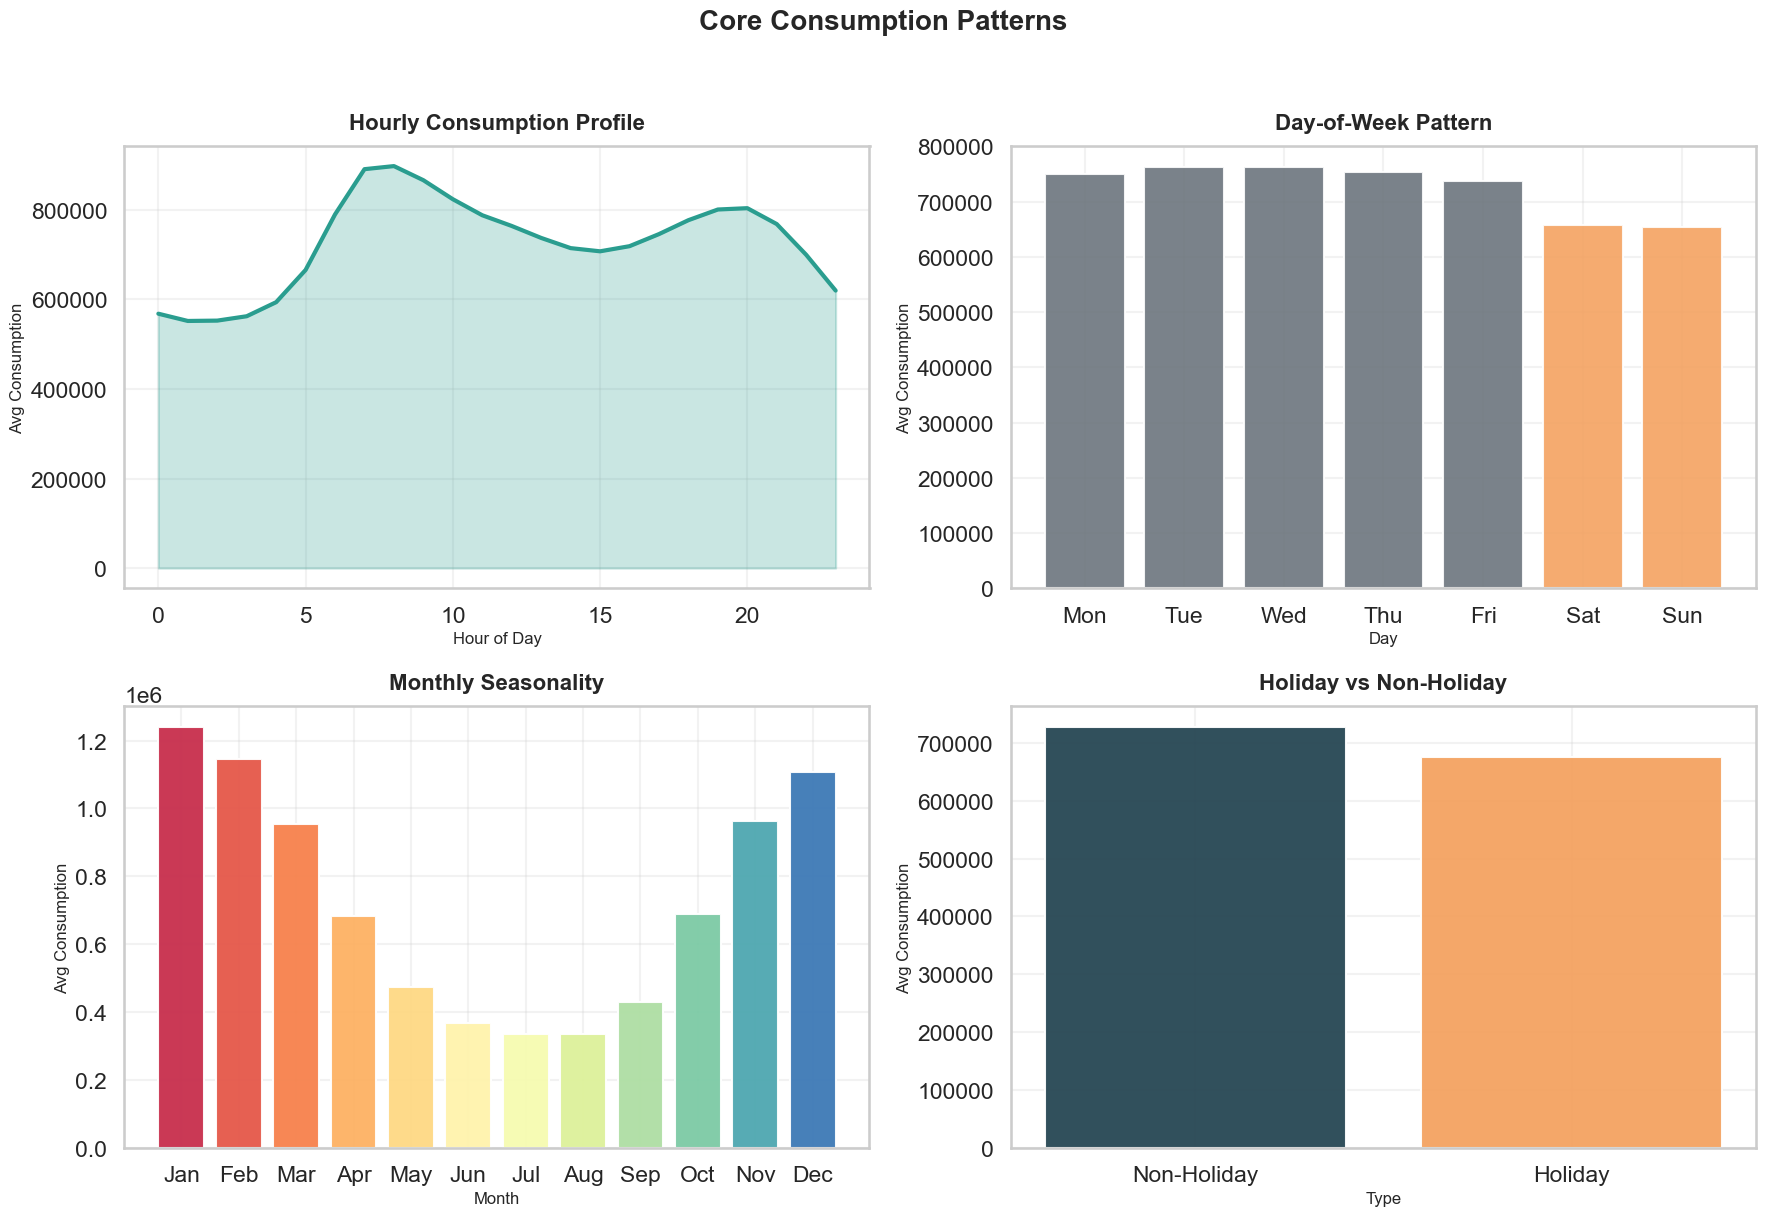

In [11]:
hourly = df.groupby("hour", observed=True)["consumption_total"].mean()
dow = df.groupby("day_of_week", observed=True)["consumption_total"].mean()
monthly = df.groupby("month", observed=True)["consumption_total"].mean()
holiday_avg = df.groupby("holiday", observed=True)["consumption_total"].mean()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Hourly profile
axes[0, 0].plot(hourly.index, hourly.values, color=PALETTE["consumption"], linewidth=3)
axes[0, 0].fill_between(
    hourly.index, hourly.values, alpha=0.25, color=PALETTE["consumption"]
)
style_axis(axes[0, 0], "Hourly Consumption Profile", "Hour of Day", "Avg Consumption")

# Day-of-week profile
dow_colors = [PALETTE["holiday"] if i in [5, 6] else "#6c757d" for i in dow.index]
axes[0, 1].bar(
    [WEEKDAY_NAMES.get(i, str(i)) for i in dow.index],
    dow.values,
    color=dow_colors,
    alpha=0.9,
)
style_axis(axes[0, 1], "Day-of-Week Pattern", "Day", "Avg Consumption")

# Monthly seasonality
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
axes[1, 0].bar(
    monthly.index, monthly.values, color=sns.color_palette("Spectral", 12), alpha=0.95
)
axes[1, 0].set_xticks(range(1, 13), month_labels)
style_axis(axes[1, 0], "Monthly Seasonality", "Month", "Avg Consumption")

# Holiday effect
h_labels = ["Non-Holiday", "Holiday"]
h_values = [holiday_avg.get(0, np.nan), holiday_avg.get(1, np.nan)]
axes[1, 1].bar(
    h_labels,
    h_values,
    color=[PALETTE["non_holiday"], PALETTE["holiday"]],
    alpha=0.95,
)
style_axis(axes[1, 1], "Holiday vs Non-Holiday", "Type", "Avg Consumption")

fig.suptitle("Core Consumption Patterns", fontsize=20, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Hour x Month Heatmap (Consumption Intensity)

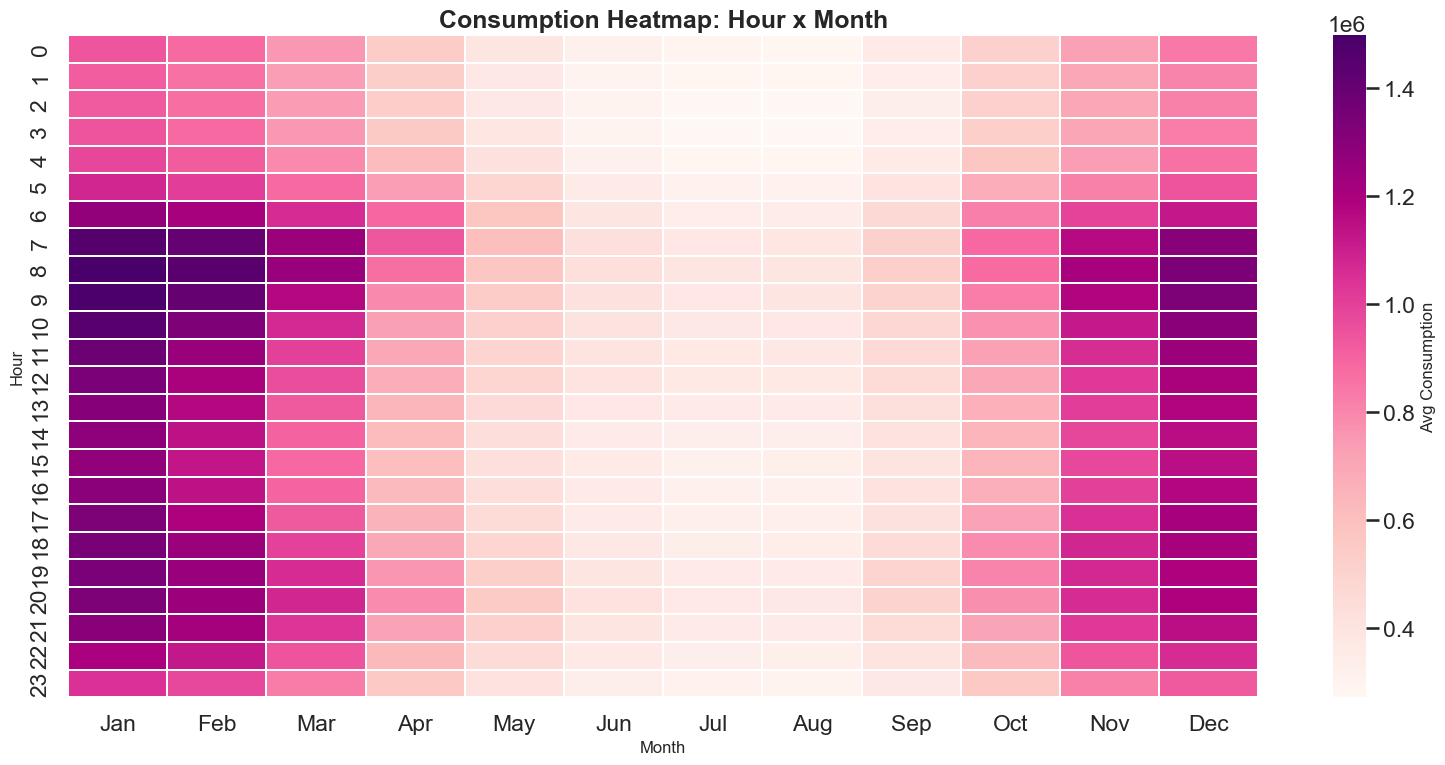

In [12]:
pivot = df.pivot_table(
    values="consumption_total",
    index="hour",
    columns="month",
    aggfunc="mean",
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    pivot,
    cmap="RdPu",
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Avg Consumption"},
)
plt.title("Consumption Heatmap: Hour x Month", fontsize=18, weight="bold")
plt.xlabel("Month")
plt.ylabel("Hour")
plt.xticks(
    ticks=np.arange(0.5, 12.5, 1),
    labels=[
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
    rotation=0,
)
plt.tight_layout()
plt.show()

## 4 Network Consumption Analysis

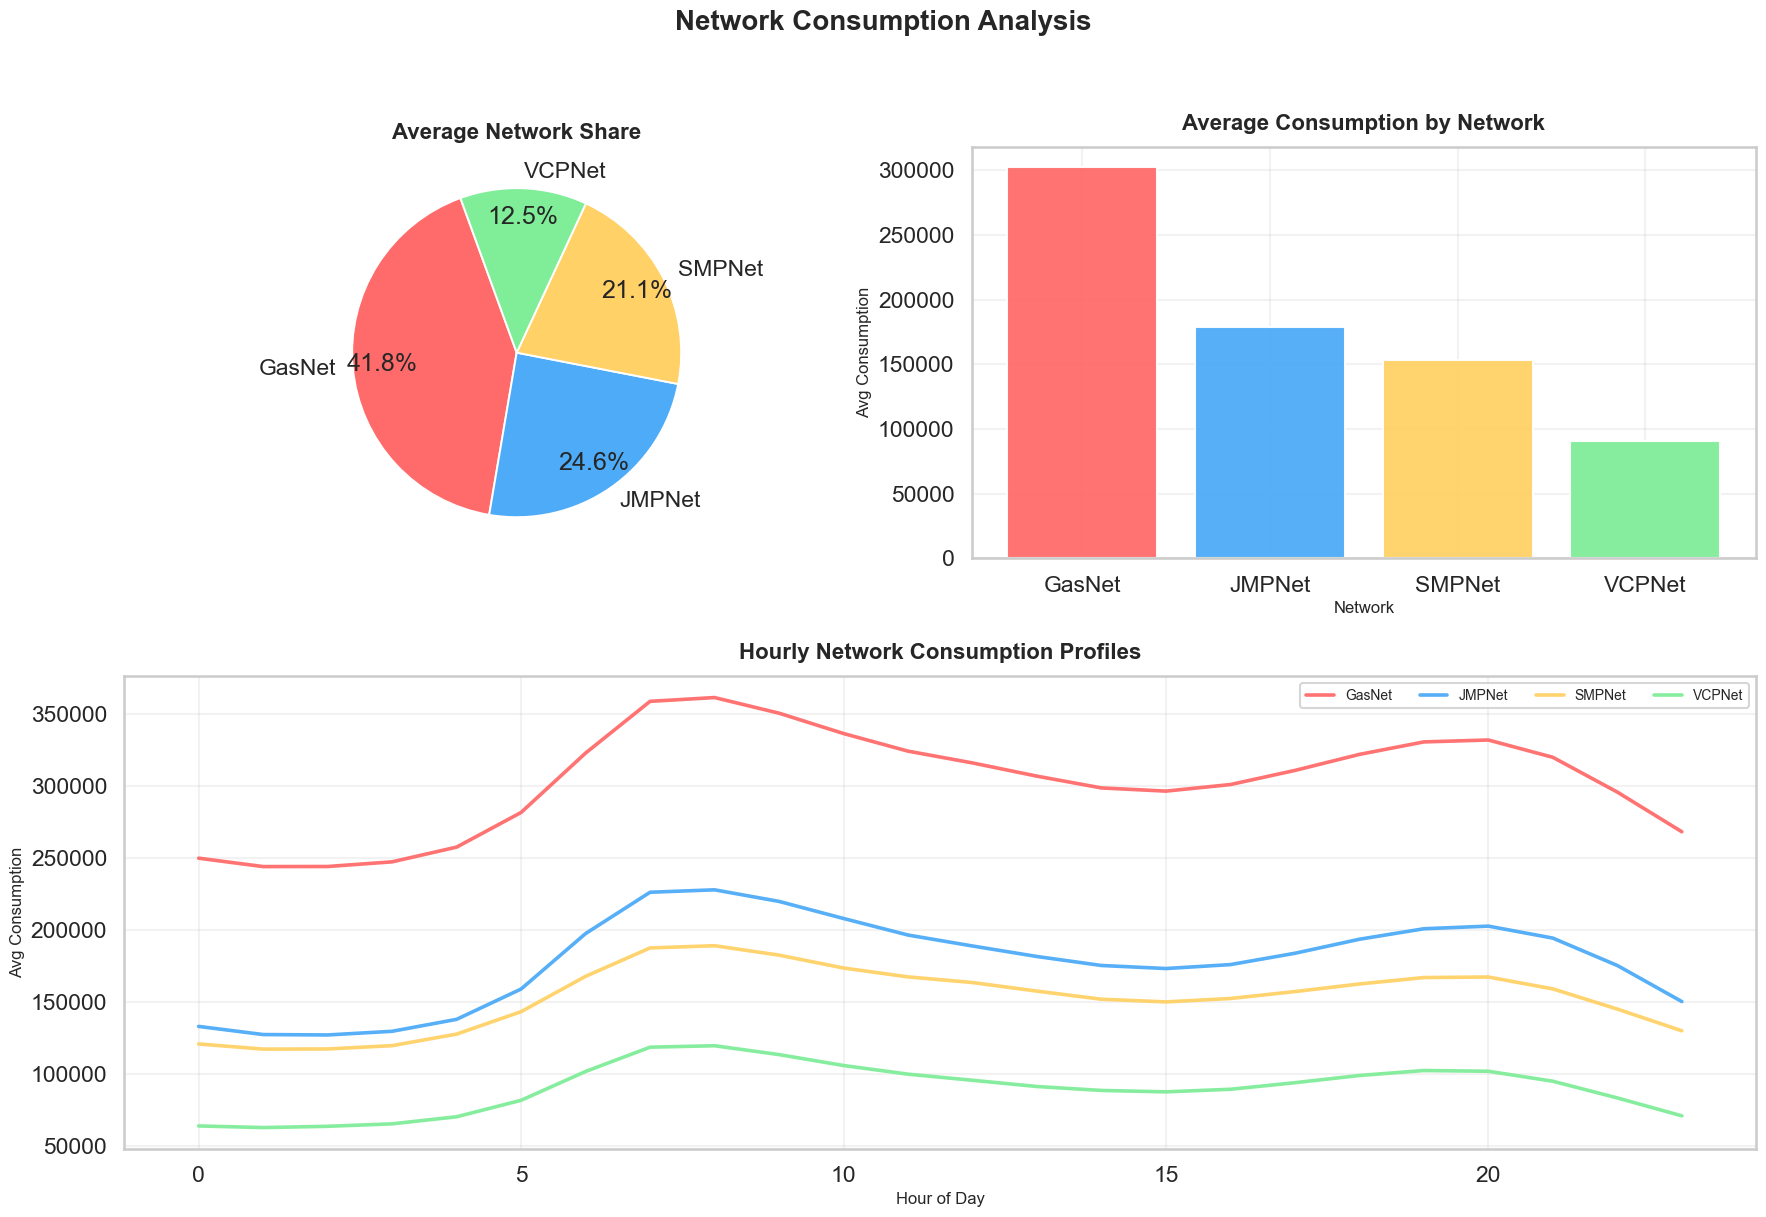

In [13]:
network_cols = [
    "consumption_gasnet",
    "consumption_jmpnet",
    "consumption_smpnet",
    "consumption_vcpnet",
]

network_means = df[network_cols].mean().sort_values(ascending=False)
network_share = (network_means / network_means.sum() * 100).round(2)

hourly_network = df.groupby("hour", observed=True)[network_cols].mean()

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.15])

ax1 = fig.add_subplot(gs[0, 0])
ax1.pie(
    network_means.values,  # type: ignore
    labels=[NETWORK_LABELS[c] for c in network_means.index],
    colors=[NETWORK_COLORS[c] for c in network_means.index],
    autopct="%1.1f%%",
    startangle=110,
    pctdistance=0.82,
    wedgeprops={"edgecolor": "white", "linewidth": 1.4},
)
ax1.set_title("Average Network Share", weight="bold")

ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(
    [NETWORK_LABELS[c] for c in network_means.index],
    network_means.values,  # type: ignore
    color=[NETWORK_COLORS[c] for c in network_means.index],
    alpha=0.95,
)
style_axis(ax2, "Average Consumption by Network", "Network", "Avg Consumption")
ax2.tick_params(axis="x", rotation=0)

ax3 = fig.add_subplot(gs[1, :])
for col in network_cols:
    ax3.plot(
        hourly_network.index,
        hourly_network[col],
        linewidth=2.6,
        alpha=0.95,
        label=NETWORK_LABELS[col],
        color=NETWORK_COLORS[col],
    )
style_axis(ax3, "Hourly Network Consumption Profiles", "Hour of Day", "Avg Consumption")
ax3.legend(ncol=4, frameon=True)

fig.suptitle("Network Consumption Analysis", fontsize=20, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

network_summary = pd.DataFrame(
    {
        "network": [NETWORK_LABELS[c] for c in network_means.index],
        "avg_consumption": network_means.values,
        "share_pct": network_share.values,
    }
)

In [14]:
display(network_summary)

,network,avg_consumption,share_pct
0,GasNet,302971.384189,41.77
1,JMPNet,178605.726758,24.62
2,SMPNet,153312.168376,21.14
3,VCPNet,90444.627628,12.47


## 5 Consumption vs Temperature

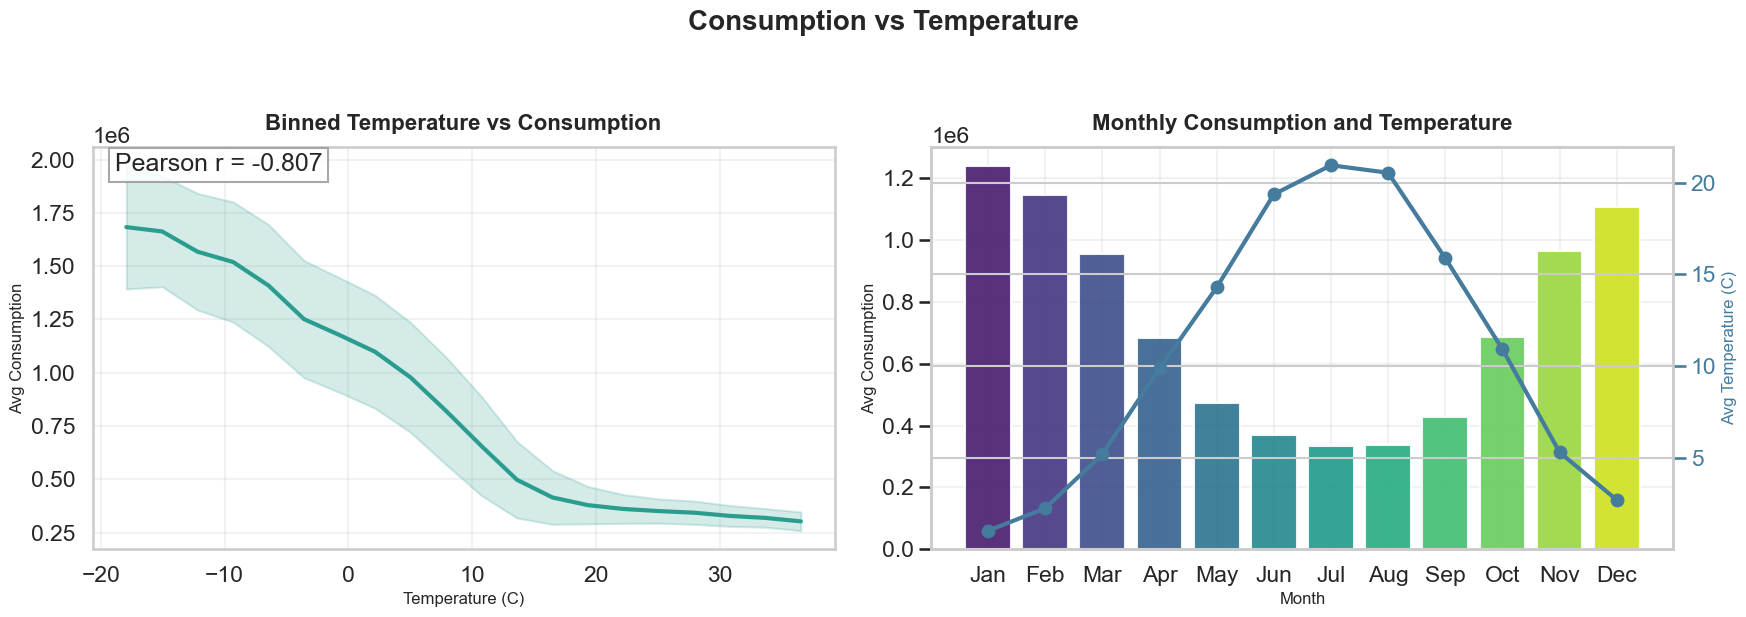

In [15]:
temp_bins = pd.cut(df["temperature_2m"], bins=20)
temp_profile = (
    df.groupby(temp_bins, observed=True)["consumption_total"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
temp_profile["temp_center"] = temp_profile["temperature_2m"].apply(lambda x: x.mid)

monthly_weather = df.groupby("month", observed=True).agg(
    consumption_avg=("consumption_total", "mean"),
    temp_avg=("temperature_2m", "mean"),
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].plot(
    temp_profile["temp_center"],
    temp_profile["mean"],
    color=PALETTE["consumption"],
    linewidth=3,
)
axes[0].fill_between(
    temp_profile["temp_center"],
    temp_profile["mean"] - temp_profile["std"].fillna(0),
    temp_profile["mean"] + temp_profile["std"].fillna(0),
    color=PALETTE["consumption"],
    alpha=0.2,
)
style_axis(
    axes[0], "Binned Temperature vs Consumption", "Temperature (C)", "Avg Consumption"
)

ax2 = axes[1]
bars = ax2.bar(
    monthly_weather.index,
    monthly_weather["consumption_avg"],
    color=sns.color_palette("viridis", 12),
    alpha=0.9,
)
style_axis(ax2, "Monthly Consumption and Temperature", "Month", "Avg Consumption")
ax2.set_xticks(
    range(1, 13),
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
)

ax2_t = ax2.twinx()
ax2_t.plot(
    monthly_weather.index,
    monthly_weather["temp_avg"],
    color=PALETTE["temperature"],
    linewidth=3,
    marker="o",
)
ax2_t.set_ylabel("Avg Temperature (C)", color=PALETTE["temperature"])
ax2_t.tick_params(axis="y", colors=PALETTE["temperature"])

corr = df[["consumption_total", "temperature_2m"]].corr().iloc[0, 1]
axes[0].text(
    0.03,
    0.94,
    f"Pearson r = {corr:.3f}",
    transform=axes[0].transAxes,
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#999"},
)

plt.suptitle("Consumption vs Temperature", fontsize=20, weight="bold", y=1.04)
plt.tight_layout()
plt.show()

## 6 Gas Price Distribution by Year

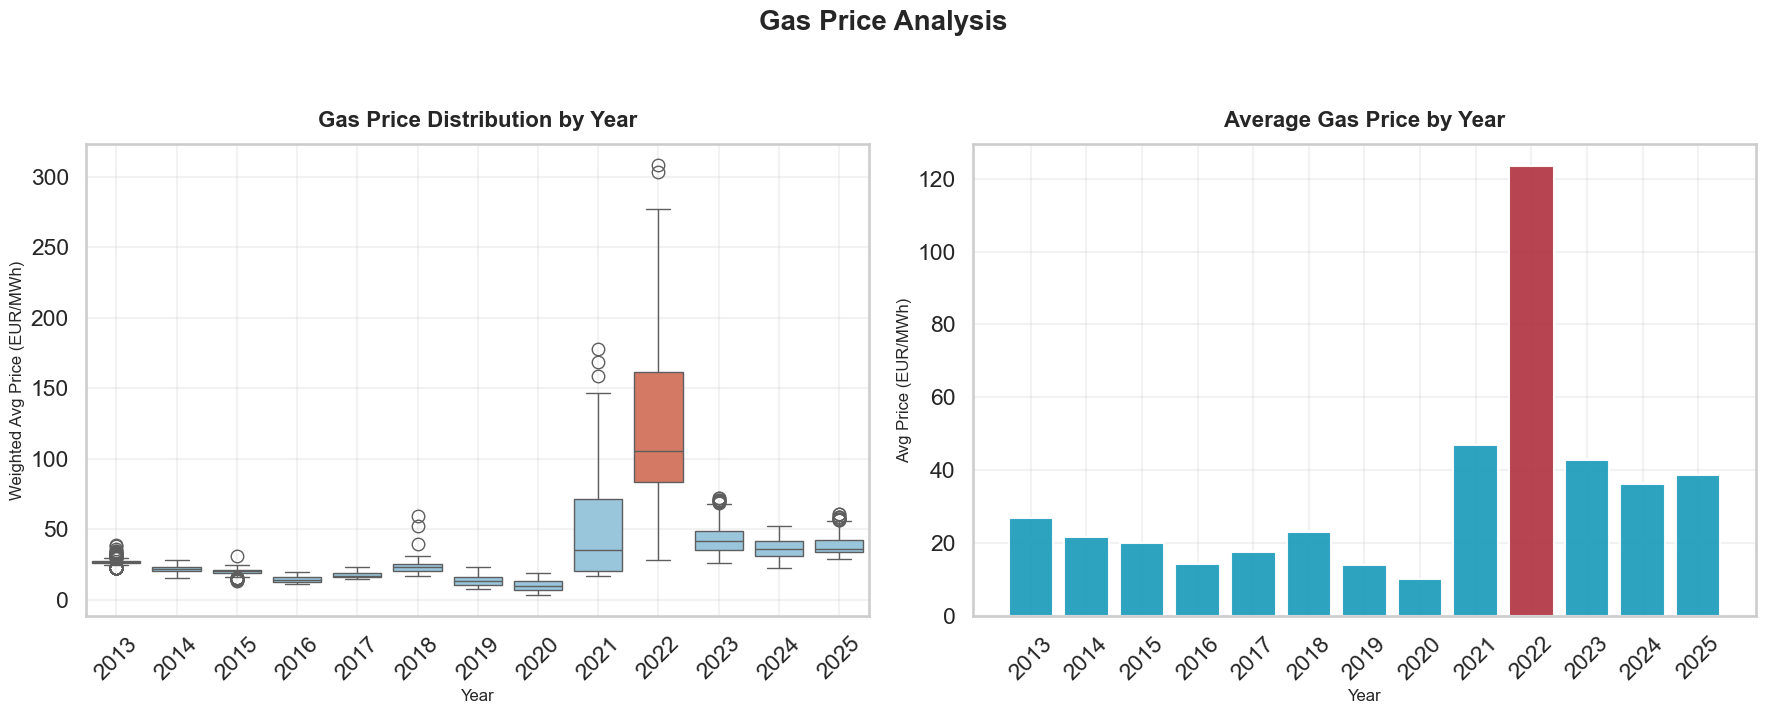

In [16]:
daily_price = (
    df.set_index("datetime")[price_cols].resample("D").first().dropna().reset_index()
)
daily_price["year"] = daily_price["datetime"].dt.year

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

years = sorted(daily_price["year"].unique())
box_palette = [PALETTE["price"] if y == 2022 else "#8ecae6" for y in years]

sns.boxplot(
    data=daily_price,
    x="year",
    y="weighted_avg_price_eur_mwh",
    hue="year",
    ax=axes[0],
    palette=box_palette,
    legend=False,
)
style_axis(
    axes[0], "Gas Price Distribution by Year", "Year", "Weighted Avg Price (EUR/MWh)"
)
axes[0].tick_params(axis="x", rotation=45)

yearly_avg_price = daily_price.groupby("year", observed=True)[
    "weighted_avg_price_eur_mwh"
].mean()
bar_colors = [
    PALETTE["price_dark"] if y == 2022 else "#219ebc" for y in yearly_avg_price.index
]
axes[1].bar(
    yearly_avg_price.index.astype(str),
    yearly_avg_price.values,
    color=bar_colors,
    alpha=0.95,
)
style_axis(axes[1], "Average Gas Price by Year", "Year", "Avg Price (EUR/MWh)")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Gas Price Analysis", fontsize=20, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

price_yearly_stats = (
    daily_price.groupby("year", observed=True)["weighted_avg_price_eur_mwh"]
    .agg(["min", "median", "mean", "max", "std"])
    .round(2)
)

In [17]:
display(price_yearly_stats)

,min,median,mean,max,std
year,,,,,
2013,22.81,26.80,26.85,38.98,2.21
2014,15.30,22.07,21.76,28.22,2.82
2015,13.61,20.70,20.14,30.83,2.12
2016,11.18,13.87,14.37,19.55,2.09
2017,14.42,16.85,17.49,23.03,2.03
2018,17.03,22.86,23.02,59.11,4.05
2019,7.69,13.55,14.06,23.23,3.83
2020,3.70,9.86,10.04,19.01,3.58
2021,16.66,34.94,47.01,177.83,32.43


## 7 Russia-Ukraine conflict context

Event marker used: `2022-02-24`.

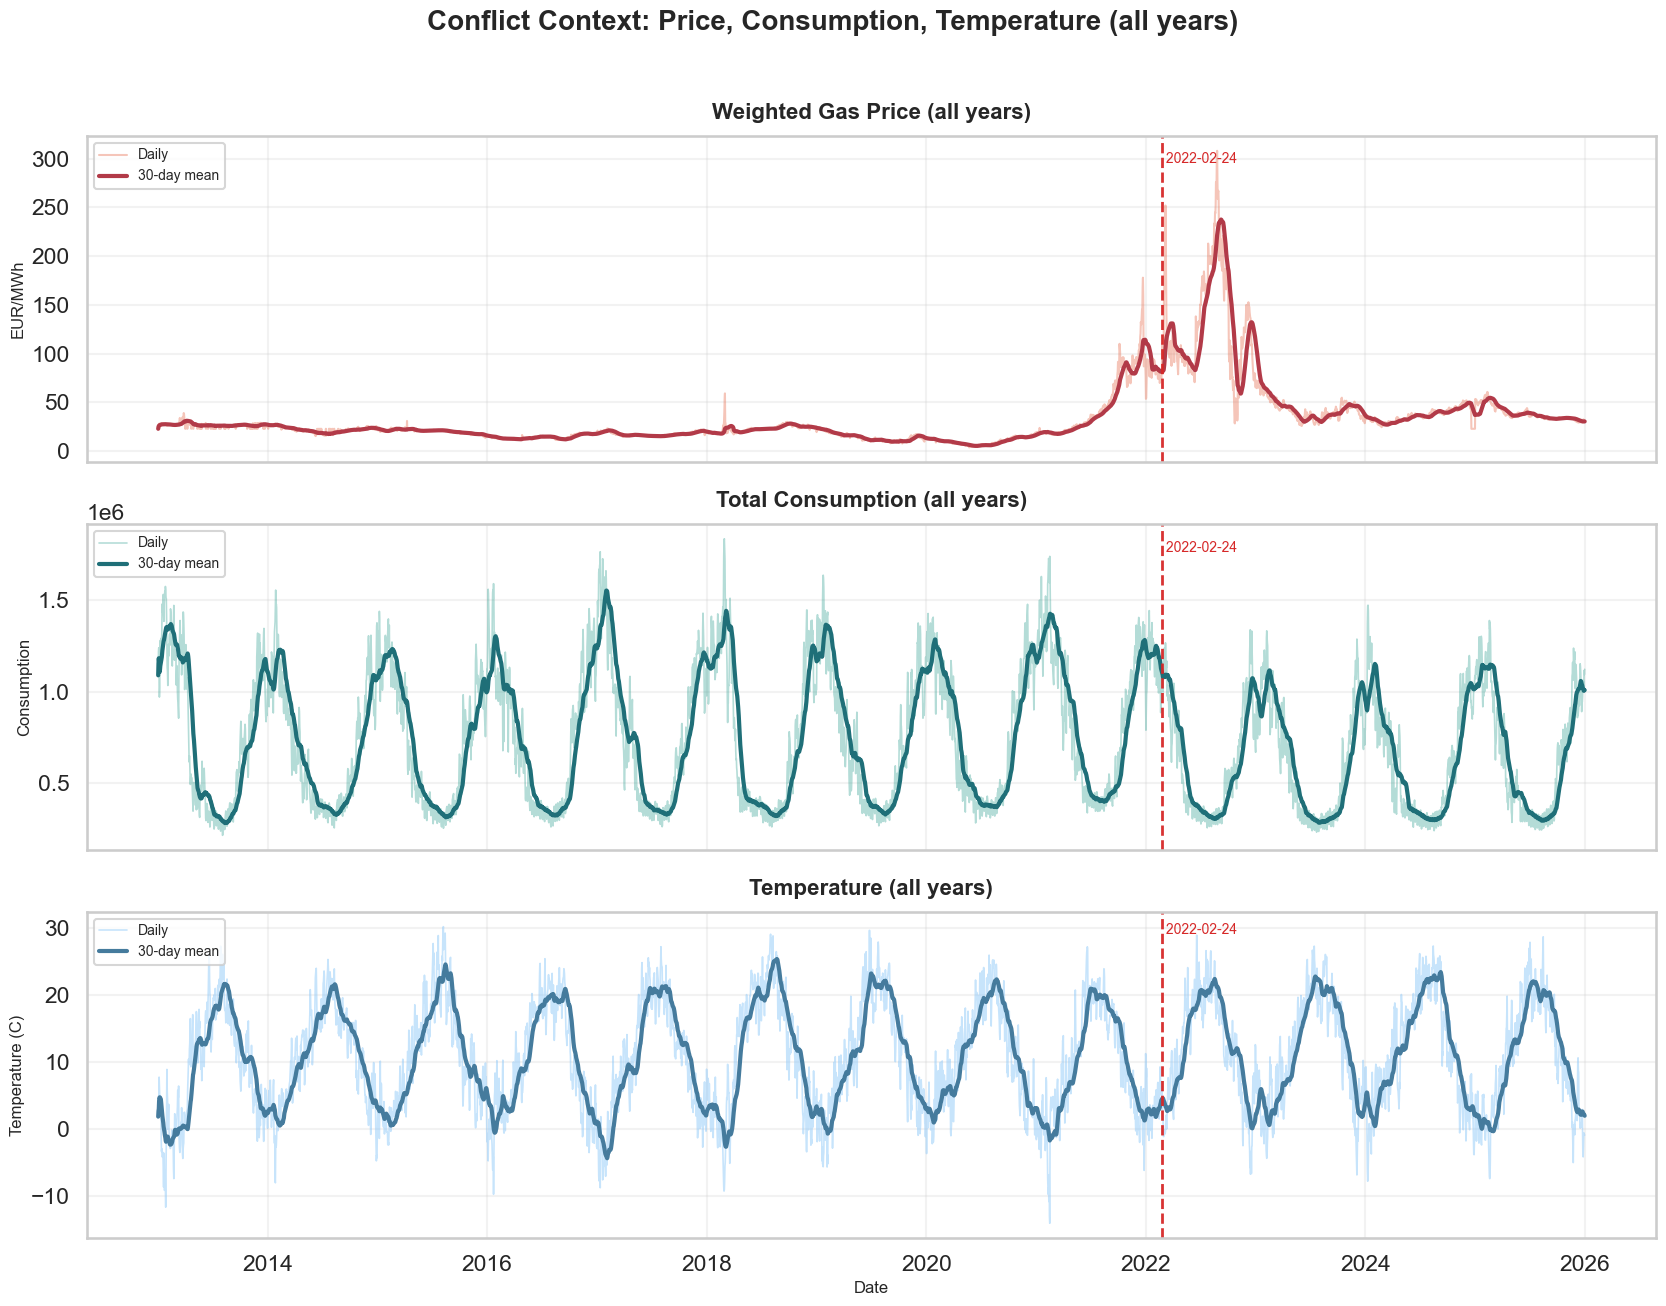

In [18]:
ukraine_event = pd.Timestamp("2022-02-24")

daily_context = (
    df.set_index("datetime")
    .resample("D")
    .agg(
        consumption_total=("consumption_total", "mean"),
        weighted_avg_price_eur_mwh=("weighted_avg_price_eur_mwh", "first"),
        temperature_2m=("temperature_2m", "mean"),
        min_price_eur_mwh=("min_price_eur_mwh", "first"),
        max_price_eur_mwh=("max_price_eur_mwh", "first"),
    )
    .dropna()
)

# use every day in the dataset, not just 2021–2023
daily_context_all = daily_context.copy()
daily_context_all["price_30d"] = (
    daily_context_all["weighted_avg_price_eur_mwh"].rolling(30, min_periods=1).mean()
)
daily_context_all["cons_30d"] = (
    daily_context_all["consumption_total"].rolling(30, min_periods=1).mean()
)
daily_context_all["temp_30d"] = (
    daily_context_all["temperature_2m"].rolling(30, min_periods=1).mean()
)

fig, axes = plt.subplots(3, 1, figsize=(17, 13), sharex=True)

axes[0].plot(
    daily_context_all.index,
    daily_context_all["weighted_avg_price_eur_mwh"],
    color=PALETTE["price"],
    alpha=0.4,
    linewidth=1.5,
    label="Daily",
)
axes[0].plot(
    daily_context_all.index,
    daily_context_all["price_30d"],
    color=PALETTE["price_dark"],
    linewidth=3,
    label="30-day mean",
)
style_axis(axes[0], "Weighted Gas Price (all years)", "", "EUR/MWh")
axes[0].legend(loc="upper left")

axes[1].plot(
    daily_context_all.index,
    daily_context_all["consumption_total"],
    color=PALETTE["consumption"],
    alpha=0.35,
    linewidth=1.2,
    label="Daily",
)
axes[1].plot(
    daily_context_all.index,
    daily_context_all["cons_30d"],
    color=PALETTE["consumption_dark"],
    linewidth=3,
    label="30-day mean",
)
style_axis(axes[1], "Total Consumption (all years)", "", "Consumption")
axes[1].legend(loc="upper left")

axes[2].plot(
    daily_context_all.index,
    daily_context_all["temperature_2m"],
    color="#90caf9",
    alpha=0.5,
    linewidth=1.2,
    label="Daily",
)
axes[2].plot(
    daily_context_all.index,
    daily_context_all["temp_30d"],
    color=PALETTE["temperature"],
    linewidth=3,
    label="30-day mean",
)
style_axis(axes[2], "Temperature (all years)", "Date", "Temperature (C)")
axes[2].legend(loc="upper left")

for ax in axes:
    ax.axvline(
        ukraine_event, color=PALETTE["event"], linestyle="--", linewidth=2, alpha=0.95
    )
    ax.text(
        ukraine_event,
        ax.get_ylim()[1] * 0.95,
        " 2022-02-24",
        color=PALETTE["event"],
        fontsize=10,
        va="top",
    )

plt.suptitle(
    "Conflict Context: Price, Consumption, Temperature (all years)",
    fontsize=20,
    weight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

# pre/post summary remains unchanged – it already uses the full daily_context
pre = daily_context.loc[: ukraine_event - pd.Timedelta(days=1)].copy()
post = daily_context.loc[ukraine_event:].copy()

pre_post_summary = pd.DataFrame(
    {
        "metric": [
            "weighted_avg_price_eur_mwh_mean",
            "consumption_total_mean",
            "temperature_2m_mean",
            "daily_price_spread_mean",
        ],
        "pre_event": [
            pre["weighted_avg_price_eur_mwh"].mean(),
            pre["consumption_total"].mean(),
            pre["temperature_2m"].mean(),
            (pre["max_price_eur_mwh"] - pre["min_price_eur_mwh"]).mean(),
        ],
        "post_event": [
            post["weighted_avg_price_eur_mwh"].mean(),
            post["consumption_total"].mean(),
            post["temperature_2m"].mean(),
            (post["max_price_eur_mwh"] - post["min_price_eur_mwh"]).mean(),
        ],
    }
)

In [19]:
pre_post_summary["relative_change_pct"] = (
    (pre_post_summary["post_event"] - pre_post_summary["pre_event"])
    / pre_post_summary["pre_event"]
    * 100
).round(2)

display(pre_post_summary)

,metric,pre_event,post_event,relative_change_pct
0,weighted_avg_price_eur_mwh_mean,22.599801,59.382365,162.76
1,consumption_total_mean,765455.668853,630062.544822,-17.69
2,temperature_2m_mean,10.414274,11.478109,10.22
3,daily_price_spread_mean,1.392045,6.297838,352.42


## 8 Some extras

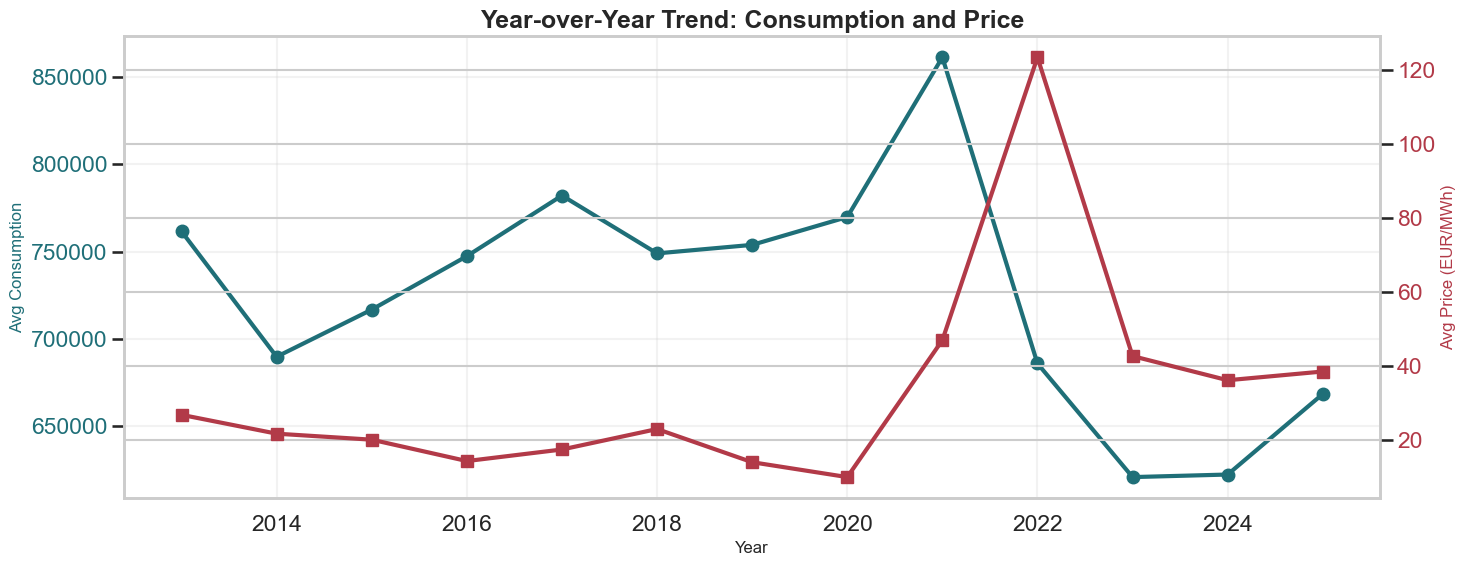

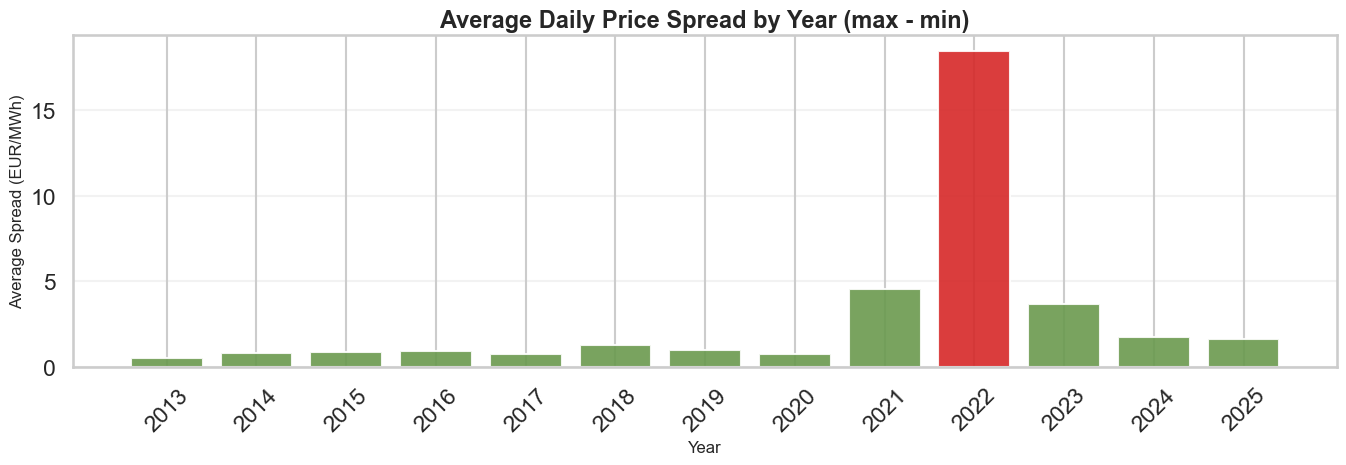

In [20]:
annual_summary = (
    df.groupby("year", observed=True)
    .agg(
        avg_consumption=("consumption_total", "mean"),
        avg_price=("weighted_avg_price_eur_mwh", "mean"),
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(
    annual_summary["year"],
    annual_summary["avg_consumption"],
    color=PALETTE["consumption_dark"],
    marker="o",
    linewidth=3,
    label="Avg Consumption",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Consumption", color=PALETTE["consumption_dark"])
ax1.tick_params(axis="y", labelcolor=PALETTE["consumption_dark"])
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    annual_summary["year"],
    annual_summary["avg_price"],
    color=PALETTE["price_dark"],
    marker="s",
    linewidth=3,
    label="Avg Price",
)
ax2.set_ylabel("Avg Price (EUR/MWh)", color=PALETTE["price_dark"])
ax2.tick_params(axis="y", labelcolor=PALETTE["price_dark"])

plt.title("Year-over-Year Trend: Consumption and Price", fontsize=18, weight="bold")
plt.tight_layout()
plt.show()

# Extra 2: daily price spread by year
price_spread_year = (
    (daily_price["max_price_eur_mwh"] - daily_price["min_price_eur_mwh"])
    .groupby(daily_price["year"])
    .mean()
)

plt.figure(figsize=(14, 5))
colors = [PALETTE["event"] if y == 2022 else "#6a994e" for y in price_spread_year.index]
plt.bar(
    price_spread_year.index.astype(str),
    price_spread_year.values,  # type: ignore
    color=colors,
    alpha=0.9,
)
plt.title("Average Daily Price Spread by Year (max - min)", fontsize=17, weight="bold")
plt.xlabel("Year")
plt.ylabel("Average Spread (EUR/MWh)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()